In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

df = pd.read_csv("../data/processed/trials_clean.csv")

# Same cleaning as notebook 1
df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")
df["completion_date"] = pd.to_datetime(df["completion_date"], errors="coerce")
df["duration_months"] = ((df["completion_date"] - df["start_date"]).dt.days / 30.44).round(1)
df["enrollment_rate"] = (df["enrollment_actual"] / df["duration_months"]).round(2)
p99 = df["enrollment_actual"].quantile(0.99)
df_clean = df[df["enrollment_actual"] <= p99].copy()

nudge = df_clean[df_clean["has_nudge"] == 1]["enrollment_actual"]
control = df_clean[df_clean["has_nudge"] == 0]["enrollment_actual"]

print(f"Nudge   : n={len(nudge):,}, mean={nudge.mean():.1f}, median={nudge.median():.1f}")
print(f"Control : n={len(control):,}, mean={control.mean():.1f}, median={control.median():.1f}")

Nudge   : n=468, mean=307.3, median=119.5
Control : n=17,989, mean=151.7, median=60.0


## Notebook 2 — Frequentist A/B Testing

**Research question:** Do trials with behavioral nudge interventions enroll 
significantly more participants than standard recruitment trials?

**Approach:**
1. Mann-Whitney U test (non-parametric — enrollment is heavily right-skewed)
2. Welch's t-test on log-transformed enrollment
3. Multiple testing correction across subgroups (Bonferroni + BH-FDR)
4. Subgroup analysis: oncology vs non-oncology, phase, sponsor class

**Why non-parametric first?** Enrollment distributions are highly skewed 
(median << mean in both groups), violating t-test normality assumptions. 
Mann-Whitney U tests for differences in the rank distribution — more robust here.

In [4]:
# --- Test 1: Mann-Whitney U (non-parametric) ---
u_stat, p_mw = stats.mannwhitneyu(nudge, control, alternative="greater")
n1, n2 = len(nudge), len(control)

# Correct rank-biserial: use two-sided U for effect size
u_twosided, _ = stats.mannwhitneyu(nudge, control, alternative="two-sided")
r_rb = 2 * u_twosided / (n1 * n2) - 1

print("=" * 50)
print("Test 1: Mann-Whitney U (one-sided: nudge > control)")
print("=" * 50)
print(f"U statistic : {u_stat:,.0f}")
print(f"p-value     : {p_mw:.2e}")
print(f"Effect size : rank-biserial r = {r_rb:.3f}")
print(f"Conclusion  : {'SIGNIFICANT' if p_mw < 0.05 else 'NOT significant'} at α=0.05")

# --- Test 2: Welch's t-test on log-transformed enrollment ---
log_nudge   = np.log1p(nudge)
log_control = np.log1p(control)
t_stat, p_t = stats.ttest_ind(log_nudge, log_control, equal_var=False)
cohens_d = (log_nudge.mean() - log_control.mean()) / np.sqrt(
    (log_nudge.std()**2 + log_control.std()**2) / 2
)

print("\n" + "=" * 50)
print("Test 2: Welch's t-test on log(enrollment)")
print("=" * 50)
print(f"t statistic : {t_stat:.3f}")
print(f"p-value     : {p_t:.2e}")
print(f"Cohen's d   : {cohens_d:.3f}")
print(f"Conclusion  : {'SIGNIFICANT' if p_t < 0.05 else 'NOT significant'} at α=0.05")

# Geometric means (back-transform from log)
gm_nudge   = np.expm1(log_nudge.mean())
gm_control = np.expm1(log_control.mean())
print(f"\nGeometric mean enrollment:")
print(f"  Nudge   : {gm_nudge:.1f}")
print(f"  Control : {gm_control:.1f}")
print(f"  Ratio   : {gm_nudge/gm_control:.2f}x")

Test 1: Mann-Whitney U (one-sided: nudge > control)
U statistic : 5,505,702
p-value     : 2.29e-30
Effect size : rank-biserial r = 0.308
Conclusion  : SIGNIFICANT at α=0.05

Test 2: Welch's t-test on log(enrollment)
t statistic : 11.410
p-value     : 6.81e-27
Cohen's d   : 0.554
Conclusion  : SIGNIFICANT at α=0.05

Geometric mean enrollment:
  Nudge   : 131.4
  Control : 65.4
  Ratio   : 2.01x


## Subgroup Analysis with Multiple Testing Correction

The overall test shows a highly significant difference in enrollment between nudge 
and control trials. But is this effect consistent across subgroups, or driven by 
a specific subset (e.g. large federal trials)?

**Subgroups tested:** oncology vs non-oncology, trial phase, sponsor class, 
randomization type — 12 subgroups total.

**Multiple testing problem:** Running 12 tests at α=0.05 means ~60% chance of 
at least one false positive by chance alone. We correct using two methods of 
increasing stringency:

- **Benjamini-Hochberg FDR** — controls the expected proportion of false 
  discoveries. Less conservative, a good first filter.
- **Bonferroni** — controls family-wise error rate (FWER), dividing α by 
  number of tests: α = 0.05/12 = 0.004. More conservative.

A finding that survives Bonferroni is the most robust,  it automatically 
passes BH-FDR as well. Findings that pass FDR but not Bonferroni are 
suggestive but require caution.

In [6]:
# Define subgroups to test
subgroups = {
    "All trials"           : df_clean,
    "Oncology"             : df_clean[df_clean["is_oncology"] == 1],
    "Non-oncology"         : df_clean[df_clean["is_oncology"] == 0],
    "Phase 1"              : df_clean[df_clean["phase"] == "PHASE1"],
    "Phase 2"              : df_clean[df_clean["phase"] == "PHASE2"],
    "Phase 3"              : df_clean[df_clean["phase"] == "PHASE3"],
    "Industry sponsor"     : df_clean[df_clean["sponsor_class"] == "INDUSTRY"],
    "NIH sponsor"          : df_clean[df_clean["sponsor_class"] == "NIH"],
    "Federal sponsor"      : df_clean[df_clean["sponsor_class"] == "FED"],
    "Other sponsor"        : df_clean[df_clean["sponsor_class"] == "OTHER"],
    "Randomized"           : df_clean[df_clean["allocation"] == "RANDOMIZED"],
    "Non-randomized"       : df_clean[df_clean["allocation"] == "NON_RANDOMIZED"],
}

results = []
for name, subset in subgroups.items():
    n = subset["has_nudge"].sum()
    c = (subset["has_nudge"] == 0).sum()
    if n < 10:
        continue
    g_nudge   = np.log1p(subset[subset["has_nudge"] == 1]["enrollment_actual"])
    g_control = np.log1p(subset[subset["has_nudge"] == 0]["enrollment_actual"])
    t, p = stats.ttest_ind(g_nudge, g_control, equal_var=False)
    gm_n = np.expm1(g_nudge.mean())
    gm_c = np.expm1(g_control.mean())
    results.append({
        "Subgroup"        : name,
        "n_nudge"         : n,
        "n_control"       : c,
        "gm_nudge"        : round(gm_n, 1),
        "gm_control"      : round(gm_c, 1),
        "ratio"           : round(gm_n / gm_c, 2) if gm_c > 0 else np.nan,
        "p_raw"           : p,
    })

results_df = pd.DataFrame(results)

# Multiple testing correction
reject_bonf, p_bonf, _, _ = multipletests(results_df["p_raw"], method="bonferroni")
reject_fdr,  p_fdr,  _, _ = multipletests(results_df["p_raw"], method="fdr_bh")

results_df["p_bonferroni"] = p_bonf.round(4)
results_df["p_fdr_bh"]     = p_fdr.round(4)
results_df["sig_bonf"]     = reject_bonf
results_df["sig_fdr"]      = reject_fdr

# Format p-values properly — never display as 0
def fmt_p(p):
    if p < 0.0001:
        return "<0.0001"
    return f"{p:.4f}"

display_df = results_df[["Subgroup","n_nudge","n_control","gm_nudge","gm_control",
                          "ratio","p_raw","p_bonferroni","sig_bonf","sig_fdr"]].copy()
display_df["p_raw"]         = display_df["p_raw"].apply(lambda x: f"{x:.2e}")
display_df["p_bonferroni"]  = display_df["p_bonferroni"].apply(fmt_p)
display_df["p_fdr_bh"]      = results_df["p_fdr_bh"].apply(fmt_p)

print(display_df.to_string(index=False))

        Subgroup  n_nudge  n_control  gm_nudge  gm_control  ratio    p_raw p_bonferroni  sig_bonf  sig_fdr p_fdr_bh
      All trials      468      17989     131.4        65.4   2.01 6.81e-27      <0.0001      True     True  <0.0001
        Oncology       50       2317     129.6        57.9   2.24 2.19e-04       0.0017      True     True   0.0003
    Non-oncology      418      15672     131.7        66.6   1.98 1.32e-23      <0.0001      True     True  <0.0001
Industry sponsor       15       5356     126.5        79.8   1.59 1.97e-01       1.0000     False    False   0.2255
 Federal sponsor       15        184     111.7        70.8   1.58 3.41e-01       1.0000     False    False   0.3409
   Other sponsor      430      11699     130.7        59.1   2.21 2.66e-31      <0.0001      True     True  <0.0001
      Randomized      401      12300     148.8        83.7   1.78 2.44e-18      <0.0001      True     True  <0.0001
  Non-randomized       18       1796     137.4        49.7   2.77 5.41e-

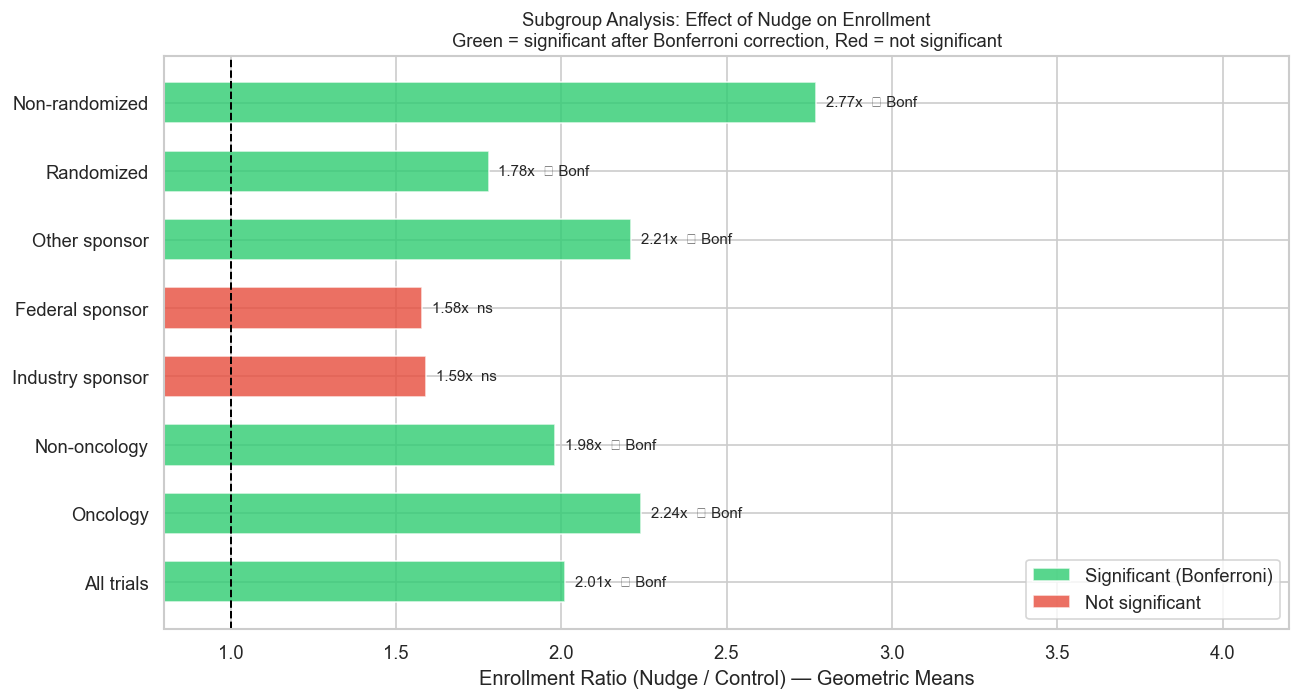

Saved ✓


In [7]:
fig, ax = plt.subplots(figsize=(11, 6))

colors = ["#2ecc71" if s else "#e74c3c" for s in results_df["sig_bonf"]]
y_pos = range(len(results_df))

ax.barh(list(y_pos), results_df["ratio"], color=colors, alpha=0.8, height=0.6)
ax.axvline(x=1.0, color="black", linestyle="--", linewidth=1.2, label="No effect (ratio=1)")

for i, (_, row) in enumerate(results_df.iterrows()):
    sig_label = "* Bonf" if row["sig_bonf"] else ("~ FDR" if row["sig_fdr"] else "ns")
    ax.text(row["ratio"] + 0.03, i, 
            f'{row["ratio"]:.2f}x  {sig_label}', 
            va="center", fontsize=9)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(results_df["Subgroup"])
ax.set_xlabel("Enrollment Ratio (Nudge / Control) — Geometric Means")
ax.set_title("Subgroup Analysis: Effect of Nudge on Enrollment\n"
             "Green = significant after Bonferroni correction, Red = not significant",
             fontsize=11)
ax.set_xlim(0.8, 4.2)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#2ecc71", alpha=0.8, label="Significant (Bonferroni)"),
                   Patch(facecolor="#e74c3c", alpha=0.8, label="Not significant")]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.savefig("../figures/03_subgroup_forest.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved ✓")